## Jet Image Pre-training with Vision Transformer

This notebook sets up a self-supervised pre-training pipeline for jet images using an unlabelled HDF5 dataset.

1. **Data Inspection** – Open the HDF5 file and examine the structure/shape of the `jet` dataset (125×125×8 images with 8 channels).
2. **PyTorch Dataset** – Define `JetUnlabelledDataset`, which lazily loads jet images, converts them to `(C, H, W)` tensors, and applies zero-mean/unit-variance normalization.
3. **Train / Val Split & DataLoaders** – Split the dataset 95/5 into training and validation sets and wrap them in `DataLoader`s for batched iteration.

In [1]:
import h5py

with h5py.File('data/Dataset_Specific_Unlabelled.h5', 'r') as f:
    print("Top-level keys:", list(f.keys()))

    jet = f['jet']
    print("Type of 'jet':", type(jet))

    # If it's a dataset:
    if isinstance(jet, h5py.Dataset):
        print("Shape:", jet.shape)
        first = jet[0]
        print("First item shape:", first.shape)

    # If it's a group (folder), inspect deeper:
    if isinstance(jet, h5py.Group):
        print("Keys inside 'jet':", list(jet.keys()))

Top-level keys: ['jet']
Type of 'jet': <class 'h5py._hl.dataset.Dataset'>
Shape: (60000, 125, 125, 8)
First item shape: (125, 125, 8)


In [2]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

class JetUnlabelledDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        self.file = None  # opened lazily

        # read shape without keeping file open
        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # open file inside worker if needed
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")
        
        x = self.file["jet"][idx]  # (125,125,8)
        x = torch.tensor(x, dtype=torch.float32)

        # convert to (C,H,W)
        x = x.permute(2, 0, 1)

        # optional: simple normalization
        x = (x - x.mean()) / (x.std() + 1e-6)

        return x

In [3]:
from torch.utils.data import random_split

dataset = JetUnlabelledDataset("data/Dataset_Specific_Unlabelled.h5")

val_size = int(0.05 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

## Sanity Check: Visualizing Jet Channels

Before training any model, we must verify that the input data looks reasonable.

Each jet sample has shape (8, 125, 125), meaning:
- 8 feature channels
- 125×125 spatial grid per channel

These are not RGB images. Each channel encodes detector-level physical information.
If the data contains mostly zeros, extreme outliers, or unexpected structure,
a transformer may learn meaningless patterns.

We will:
- Sample a random jet
- Visualize a few of its channels
- Inspect value ranges

This prevents silent failure during training.

Sample shape: torch.Size([8, 125, 125])
Min value: -0.08462045341730118
Max value: 24.978349685668945
Mean value: -1.7578125621753315e-08
Std value: 0.9999998211860657


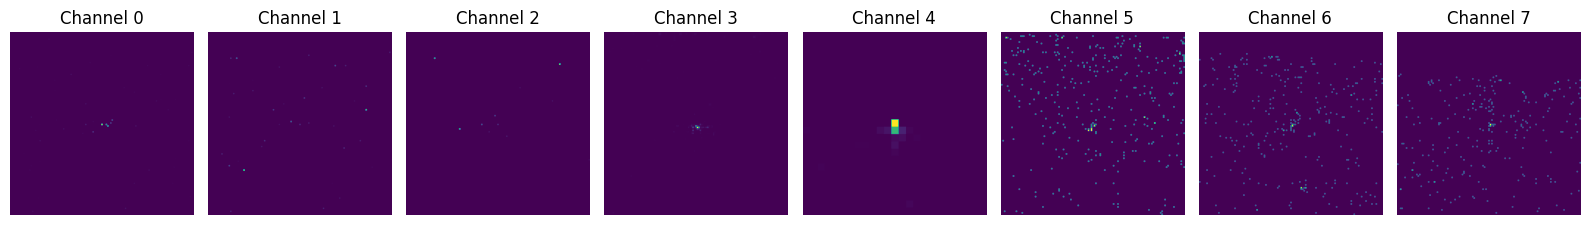

In [9]:
import matplotlib.pyplot as plt
import random

# get one random sample from training dataset
idx = random.randint(0, len(train_ds)-1)
sample = train_ds[idx]   # shape: (8,125,125)

print("Sample shape:", sample.shape)
print("Min value:", sample.min().item())
print("Max value:", sample.max().item())
print("Mean value:", sample.mean().item())
print("Std value:", sample.std().item())

# visualize first 4 channels
num_channels_to_plot = 8

fig, axes = plt.subplots(1, num_channels_to_plot, figsize=(16,4))

for i in range(num_channels_to_plot):
    axes[i].imshow(sample[i].cpu(), cmap="viridis")
    axes[i].set_title(f"Channel {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import torch
import torch.nn as nn

class PatchEmbed(nn.Module):
    def __init__(self, in_ch=8, embed_dim=256, patch=5):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch,
                              stride=patch)

    def forward(self, x):
        x = self.proj(x)          # (B, embed_dim, 25, 25)
        x = x.flatten(2)          # (B, embed_dim, 625)
        x = x.transpose(1, 2)     # (B, 625, embed_dim)
        return x

# test
patch_embed = PatchEmbed()
batch = next(iter(train_loader))

tokens = patch_embed(batch)
print("Input batch shape:", batch.shape)
print("Token shape:", tokens.shape)

Input batch shape: torch.Size([32, 8, 125, 125])
Token shape: torch.Size([32, 625, 256])


## Pretraining: Masked Autoencoder for Jet Representation Learning

We pretrain a Vision Transformer encoder on the unlabelled jet dataset using a masked reconstruction objective.

Each jet image (8 × 125 × 125) is split into 5×5 patches → 625 tokens.

During training:
- 60% of patches are randomly masked
- Encoder processes only visible patches
- A lightweight decoder reconstructs the original patches
- Loss = Mean Squared Error between reconstructed and original patches

Why this works:
The model must learn global jet structure to reconstruct missing regions.
This produces useful representations for downstream tasks like
mass regression and classification.

After pretraining, we will:
- Save encoder weights
- Fine-tune on labelled dataset
- Compare against training from scratch

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# -----------------------
# Patch embedding
# -----------------------
class PatchEmbed(nn.Module):
    def __init__(self, in_ch=8, embed_dim=256, patch=5):
        super().__init__()
        self.patch = patch
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch,
                              stride=patch)

    def forward(self, x):
        x = self.proj(x)                        # (B, D, 25, 25)
        B, D, H, W = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()  # (B, 25, 25, D)
        x = x.reshape(B, H * W, D)              # (B, 625, D)
        return x

# -----------------------
# Attention block (stable)
# -----------------------
class Attention(nn.Module):
    def __init__(self, dim, heads=8):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

    def forward(self, x):
        y = self.norm(x)
        y, _ = self.attn(y, y, y, need_weights=False)
        return y

class Block(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = Attention(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )
        self.n2 = nn.LayerNorm(dim)

    def forward(self,x):
        x = x + self.attn(x)
        x = x + self.ff(self.n2(x))
        return x

# -----------------------
# Encoder
# -----------------------
class Encoder(nn.Module):
    def __init__(self, dim=256, depth=4):
        super().__init__()
        self.patch = PatchEmbed()
        self.pos = nn.Parameter(torch.randn(1, 625, dim))
        self.blocks = nn.Sequential(*[Block(dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.patch(x)
        x = x + self.pos
        x = self.blocks(x)
        x = self.norm(x)
        return x

# -----------------------
# MAE model
# -----------------------
class MAE(nn.Module):
    def __init__(self, dim=256, mask_ratio=0.6):
        super().__init__()
        self.encoder = Encoder(dim)
        self.decoder = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, 8*5*5)
        )
        self.mask_ratio = mask_ratio
        self.patch_size = 5

    def patchify(self, imgs):
        B, C, H, W = imgs.shape
        p = self.patch_size
        h, w = H // p, W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()  # (B, h, w, C, p, p)
        x = x.reshape(B, h * w, C * p * p)
        return x

    def forward(self, x):
        B = x.size(0)

        target = self.patchify(x)
        tokens = self.encoder.patch(x)

        N = tokens.size(1)
        mask_count = int(N * self.mask_ratio)

        noise = torch.rand(B, N, device=x.device)
        ids = torch.argsort(noise, dim=1)
        keep = ids[:, mask_count:]

        visible = torch.gather(
            tokens, 1,
            keep.unsqueeze(-1).expand(-1, -1, tokens.size(-1))
        )

        encoded = self.encoder.blocks(
            visible + self.encoder.pos[:, :visible.size(1)]
        )
        encoded = self.encoder.norm(encoded)

        recon_visible = self.decoder(encoded)

        target_visible = torch.gather(
            target, 1,
            keep.unsqueeze(-1).expand(-1, -1, target.size(-1))
        )

        loss = ((recon_visible - target_visible)**2).mean()
        return loss

Using device: cuda


Epoch 1/10:   0%|          | 0/1782 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 1782/1782 [01:47<00:00, 16.57it/s, loss=0.0565]


Epoch 1: Train=0.1894 | Val=0.0710


Epoch 2/10: 100%|██████████| 1782/1782 [01:33<00:00, 18.96it/s, loss=0.0501]


...

Epoch 8: Train=0.0155 | Val=0.0141


Epoch 9/10: 100%|██████████| 1782/1782 [02:26<00:00, 12.18it/s, loss=0.0179] 


Epoch 9: Train=0.0128 | Val=0.0115


Epoch 10/10: 100%|██████████| 1782/1782 [01:36<00:00, 18.40it/s, loss=0.00706]


Epoch 10: Train=0.0106 | Val=0.0095


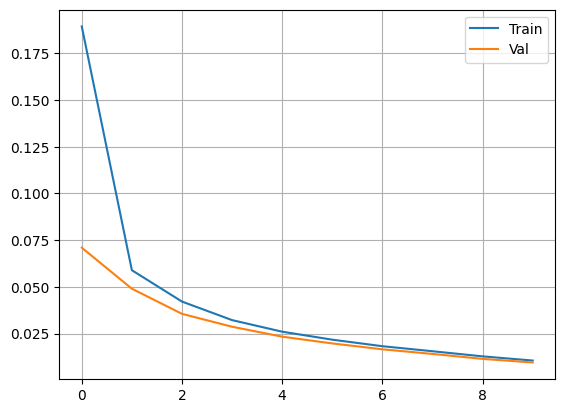

In [8]:
from tqdm import tqdm
import matplotlib.pyplot as plt

# device detection (use CUDA if available, otherwise CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

model = MAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
train_history = []
val_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        batch = batch.to(device)

        loss = model(batch)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)
    train_history.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            loss = model(batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_history.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f}")

torch.save(model.encoder.state_dict(), "pretrained_encoder.pt")

plt.plot(train_history, label="Train")
plt.plot(val_history, label="Val")
plt.legend()
plt.grid(True)
plt.show()

In [12]:

path = "data/Dataset_Specific_labelled.h5"

def explore(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"{name} -> DATASET shape={obj.shape} dtype={obj.dtype}")
    else:
        print(f"{name} -> GROUP")

with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("\nFull structure:\n")
    f.visititems(explore)

with h5py.File(path, "r") as f:
    jet = f["jet"][0]
    print("Jet shape:", jet.shape)

    for k in f.keys():
        if k != "jet":
            print(k, "sample value:", f[k][0])

Top-level keys: ['Y', 'jet']

Full structure:

Y -> DATASET shape=(10000, 1) dtype=float32
jet -> DATASET shape=(10000, 125, 125, 8) dtype=float32
Jet shape: (125, 125, 8)
Y sample value: [1.]


Shape: (10000,)
dtype: float32
Min: 0.0
Max: 1.0
Unique values (first 20): [0. 1.]
Number of unique values: 2


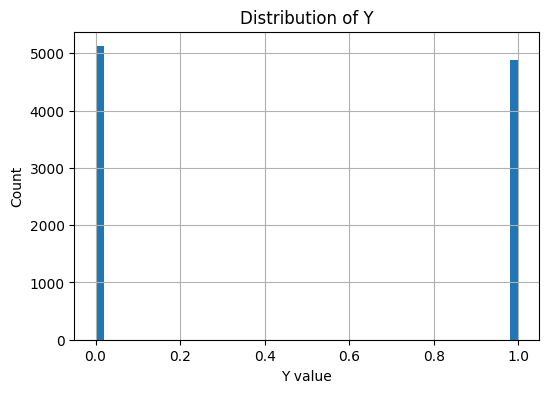

In [14]:
import numpy as np

with h5py.File(path, "r") as f:
    Y = f["Y"][:].squeeze()

print("Shape:", Y.shape)
print("dtype:", Y.dtype)
print("Min:", Y.min())
print("Max:", Y.max())
print("Unique values (first 20):", np.unique(Y)[:20])
print("Number of unique values:", len(np.unique(Y)))

# histogram
plt.figure(figsize=(6,4))
plt.hist(Y, bins=50)
plt.title("Distribution of Y")
plt.xlabel("Y value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## Fine-tuning for Binary Classification

The labelled dataset contains:

- jet: (10000, 125, 125, 8)
- Y:   binary labels {0,1}

We therefore treat this as a binary classification task.

Procedure:
1. 80% train / 20% test split
2. Fine-tune pretrained encoder with low learning rate
3. Train identical model from scratch
4. Compare test accuracy and training dynamics

Loss: Binary Cross Entropy with Logits
Metric: Accuracy

In [15]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class JetLabelledDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        self.file = None

        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")

        x = self.file["jet"][idx]
        y = self.file["Y"][idx]

        x = torch.tensor(x, dtype=torch.float32).permute(2,0,1)
        x = (x - x.mean())/(x.std()+1e-6)

        y = torch.tensor(y, dtype=torch.float32)

        return x, y

dataset = JetLabelledDataset("data/Dataset_Specific_labelled.h5")

train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size

train_ds, test_ds = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))

Train size: 8000
Test size: 2000


In [21]:
class FinetuneModel(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(256, 1)

    def forward(self, x):
        z = self.encoder(x).mean(dim=1)
        return self.head(z)   # shape: (B,1)

In [22]:
encoder_pre = Encoder()
encoder_pre.load_state_dict(torch.load("pretrained_encoder.pt", map_location=device))
encoder_pre.to(device)

model_pre = FinetuneModel(encoder_pre).to(device)
model_scratch = FinetuneModel(Encoder().to(device)).to(device)

/tmp/ipykernel_3904857/2541314185.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder_pre.load_state_dict(torch.load("pretrained_encoder.pt", map_location=device))


## Experiment: Pretrained vs Scratch

We train two models:

1. Pretrained encoder → low LR fine-tuning
2. Random initialization → same architecture

This allows us to measure the effect of representation learning.

Training pretrained model


Epoch 1: Train Loss=0.6553, Test Loss=0.6053, Train Acc=0.6281, Test Acc=0.6850


Epoch 2: Train Loss=0.5994, Test Loss=0.5922, Train Acc=0.6883, Test Acc=0.6865


Epoch 3: Train Loss=0.5918, Test Loss=0.6004, Train Acc=0.6946, Test Acc=0.6805


Epoch 4: Train Loss=0.5858, Test Loss=0.5859, Train Acc=0.6975, Test Acc=0.6885


...

Epoch 6: Train Loss=0.4062, Test Loss=0.4556, Train Acc=0.8284, Test Acc=0.7955


Epoch 7: Train Loss=0.3802, Test Loss=0.4101, Train Acc=0.8393, Test Acc=0.8305


Epoch 8: Train Loss=0.3696, Test Loss=0.3867, Train Acc=0.8458, Test Acc=0.8365


Epoch 9: Train Loss=0.3429, Test Loss=0.3911, Train Acc=0.8559, Test Acc=0.8205


Epoch 10: Train Loss=0.3298, Test Loss=0.4076, Train Acc=0.8620, Test Acc=0.8305


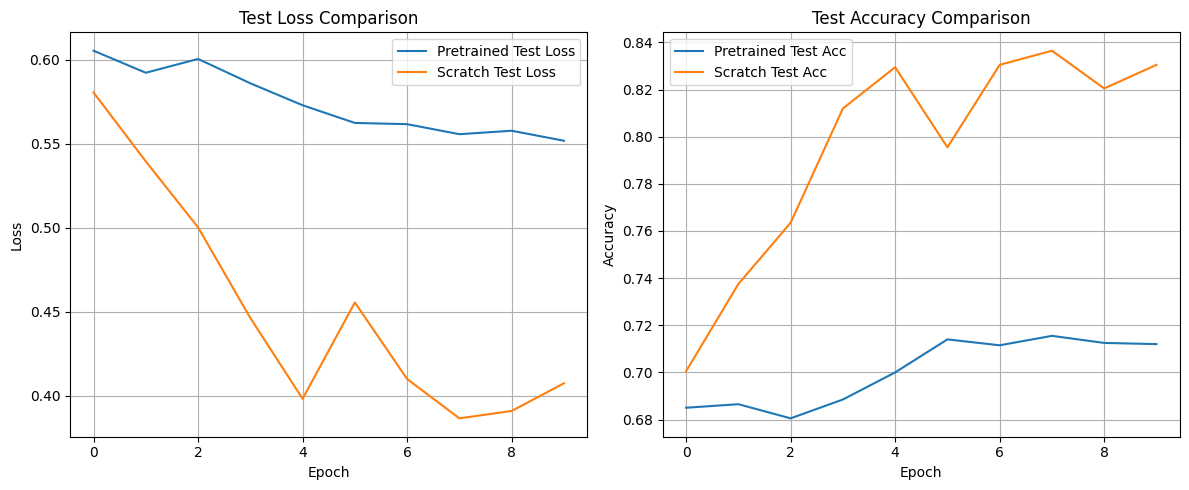

In [24]:
from tqdm import tqdm
import torch.nn as nn
import matplotlib.pyplot as plt

def train_and_evaluate(model, lr, epochs=10):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    train_loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []

    for epoch in range(epochs):

        # -------- TRAIN --------
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for x, y in tqdm(train_loader, leave=True):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_loss += loss.item()

            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss /= len(train_loader)
        train_acc = correct / total

        # -------- TEST --------
        model.eval()
        test_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                logits = model(x)
                loss = criterion(logits, y)
                test_loss += loss.item()

                preds = (torch.sigmoid(logits) > 0.5).float()
                correct += (preds == y).sum().item()
                total += y.size(0)

        test_loss /= len(test_loader)
        test_acc = correct / total

        train_loss_hist.append(train_loss)
        test_loss_hist.append(test_loss)
        train_acc_hist.append(train_acc)
        test_acc_hist.append(test_acc)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}, "
              f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

    return train_loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


# ---- Run experiments ----
print("Training pretrained model")
pre_metrics = train_and_evaluate(model_pre, lr=1e-5)

print("\nTraining scratch model")
scratch_metrics = train_and_evaluate(model_scratch, lr=1e-4)

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(pre_metrics[1], label="Pretrained Test Loss")
plt.plot(scratch_metrics[1], label="Scratch Test Loss")
plt.title("Test Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(pre_metrics[3], label="Pretrained Test Acc")
plt.plot(scratch_metrics[3], label="Scratch Test Acc")
plt.title("Test Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()